## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable. 

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes. 

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values. 

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health? 

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [11]:
!pip install -U ipykernel pandas scikit-learn matplotlib seaborn panda
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from sklearn.preprocessing import StandardScaler

mse = lambda y_true, y_pred: np.mean((y_true - y_pred) ** 2)


1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable. 

In [13]:
df = pd.read_csv('data/golub.csv')

mapper = {'allB': 0, 'allT': 0, 'aml': 1}
df['outcome'] = df['cancer'].map(mapper)

df[['Samples', 'cancer', 'outcome']].head()

y = df['outcome']
X = df.drop(['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer', 'outcome'], axis=1)

print(f'number of observations: {X.shape[0]}')
print(f'number of genes as predictors: {X.shape[1]}')


number of observations: 72
number of genes as predictors: 7129


/tmp/ipykernel_9460/2036728920.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['outcome'] = df['cancer'].map(mapper)


2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes. 

The training MSE is basically zero, which means the linear model fits the training data almost perfectly. That is not too surprising here since there are way more gene predictors than actual patient observations, so a regular linear model has enough flexibility to pretty much memorize the data.

training MSE: 1.25228e-30


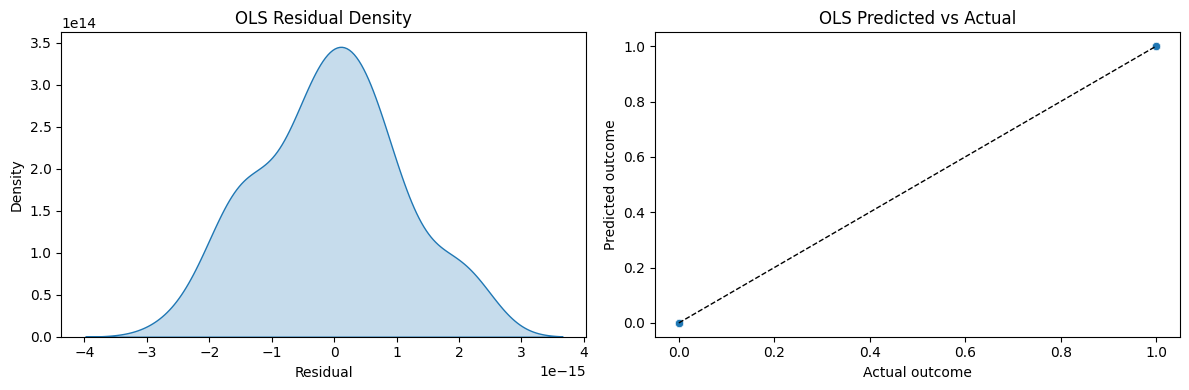

In [15]:
ols = LinearRegression().fit(X, y)
y_hat_ols = ols.predict(X)
residuals_ols = y_hat_ols - y

print(f'training MSE: {mse(y, y_hat_ols):.6g}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(residuals_ols, fill=True, ax=axes[0])
axes[0].set_title('OLS Residual Density')
axes[0].set_xlabel('Residual')

sns.scatterplot(x=y, y=y_hat_ols, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1)
axes[1].set_title('OLS Predicted vs Actual')
axes[1].set_xlabel('Actual outcome')
axes[1].set_ylabel('Predicted outcome')

plt.tight_layout()
plt.show()



3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.


The difference between the almost-zero training error and the larger cross-validated MSE is a pretty classic sign of high variance. OLS has very low bias on the training data, but outside the sample it becomes a lot less stable because it is trying to fit thousands of genes with only 72 patients. So even though it looks like a perfect fit at first, cross validation shows that it does not actually generalize nearly as well as the training error makes it seem.

Fold MSE values: [0.0244198  0.05792023 0.09224999 0.02097934 0.02126042]
Mean CV MSE: 0.043366
Median CV MSE: 0.024420
Standard deviation: 0.028108


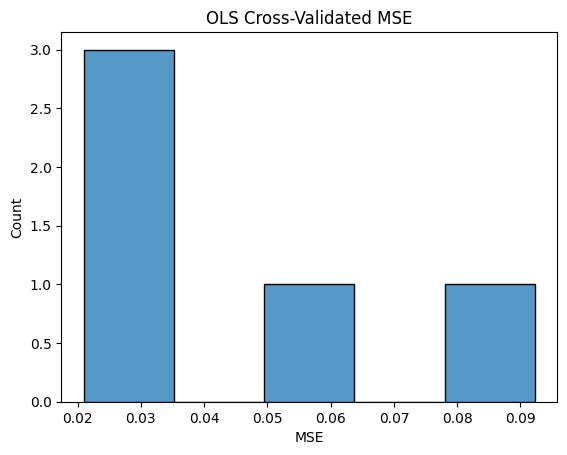

In [18]:
kfold = KFold(n_splits=5, shuffle=True, random_state=100)
cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=kfold,
    scoring='neg_mean_squared_error'
)
cv_mse = -cv_scores

print('Fold MSE values:', cv_mse)
print(f'Mean CV MSE: {cv_mse.mean():.6f}')
print(f'Median CV MSE: {np.median(cv_mse):.6f}')
print(f'Standard deviation: {cv_mse.std():.6f}')

sns.histplot(cv_mse, bins=5)
plt.title('OLS Cross-Validated MSE')
plt.xlabel('MSE')
plt.show()

